In [69]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [70]:
DATASET_PATH = r"./TinyImageNet100_2026"
CLASS_NAME_FILE = os.path.join(DATASET_PATH, "class_name.txt")

NUM_CLASSES = 10
TRAIN_IMAGES_PER_CLASS = 400
TEST_IMAGES_PER_CLASS = 100
IMAGE_SIZE = (128, 128)   # good size for feature extraction
VOCAB_SIZE = 100          # number of visual words
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [71]:
def load_class_name_mapping(class_name_file):
    """
    Reads class_name.txt and returns a dictionary:
    synset_id -> human readable class name
    """
    mapping = {}

    if not os.path.exists(class_name_file):
        print("class_name.txt not found. Semantic names will not be displayed.")
        return mapping

    with open(class_name_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # Handles lines like: n01443537 goldfish
            parts = line.split(maxsplit=1)
            if len(parts) == 2:
                mapping[parts[0]] = parts[1]
            else:
                mapping[parts[0]] = parts[0]

    return mapping

class_name_mapping = load_class_name_mapping(CLASS_NAME_FILE)
print(f"Loaded {len(class_name_mapping)} class name mappings.")

Loaded 82115 class name mappings.


In [72]:
def get_available_classes(dataset_path):
    """
    Returns class folders that contain an 'images' subfolder.
    """
    classes = []

    for item in sorted(os.listdir(dataset_path)):
        class_dir = os.path.join(dataset_path, item)
        images_dir = os.path.join(class_dir, "images")

        if os.path.isdir(class_dir) and os.path.isdir(images_dir):
            classes.append(item)

    return classes

all_classes = get_available_classes(DATASET_PATH)
print(f"Total available classes: {len(all_classes)}")
print("First 10 classes:", all_classes[:10])

Total available classes: 100
First 10 classes: ['n03255030', 'n03355925', 'n03388043', 'n03393912', 'n03400231', 'n03404251', 'n03424325', 'n03444034', 'n03447447', 'n03544143']


In [73]:
selected_classes = random.sample(all_classes, NUM_CLASSES)
selected_classes = sorted(selected_classes)   # sort only for neat display

print("Selected classes:")
for c in selected_classes:
    readable = class_name_mapping.get(c, "Unknown")
    print(f"{c} -> {readable}")

Selected classes:
n03393912 -> freight car
n03637318 -> lampshade, lamp shade
n03649909 -> lawn mower, mower
n03706229 -> magnetic compass
n03902125 -> pay-phone, pay-station
n03970156 -> plunger, plumber's helper
n03983396 -> pop bottle, soda bottle
n07695742 -> pretzel
n07747607 -> orange
n09193705 -> alp


In [74]:
def load_dataset(dataset_path, selected_classes, image_size=(128, 128)):
    X_train, y_train = [], []
    X_test, y_test = [], []

    for label, class_id in enumerate(selected_classes):
        images_dir = os.path.join(dataset_path, class_id, "images")

        image_files = [
            f for f in os.listdir(images_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
        ]

        # Alphabetical order as required by assignment
        image_files = sorted(image_files)

        train_files = image_files[:TRAIN_IMAGES_PER_CLASS]
        test_files = image_files[TRAIN_IMAGES_PER_CLASS:TRAIN_IMAGES_PER_CLASS + TEST_IMAGES_PER_CLASS]

        print(f"{class_id}: train={len(train_files)}, test={len(test_files)}")

        for fname in train_files:
            path = os.path.join(images_dir, fname)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, image_size)
            X_train.append(img)
            y_train.append(label)

        for fname in test_files:
            path = os.path.join(images_dir, fname)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, image_size)
            X_test.append(img)
            y_test.append(label)

    return np.array(X_train), np.array(y_train), np.array(X_test), np.array(y_test)

X_train, y_train, X_test, y_test = load_dataset(DATASET_PATH, selected_classes, IMAGE_SIZE)

print("\nDataset summary")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

n03393912: train=400, test=100
n03637318: train=400, test=100
n03649909: train=400, test=100
n03706229: train=400, test=100
n03902125: train=400, test=100
n03970156: train=400, test=100
n03983396: train=400, test=100
n07695742: train=400, test=100
n07747607: train=400, test=100
n09193705: train=400, test=100

Dataset summary
X_train shape: (4000, 128, 128)
y_train shape: (4000,)
X_test shape : (1000, 128, 128)
y_test shape : (1000,)


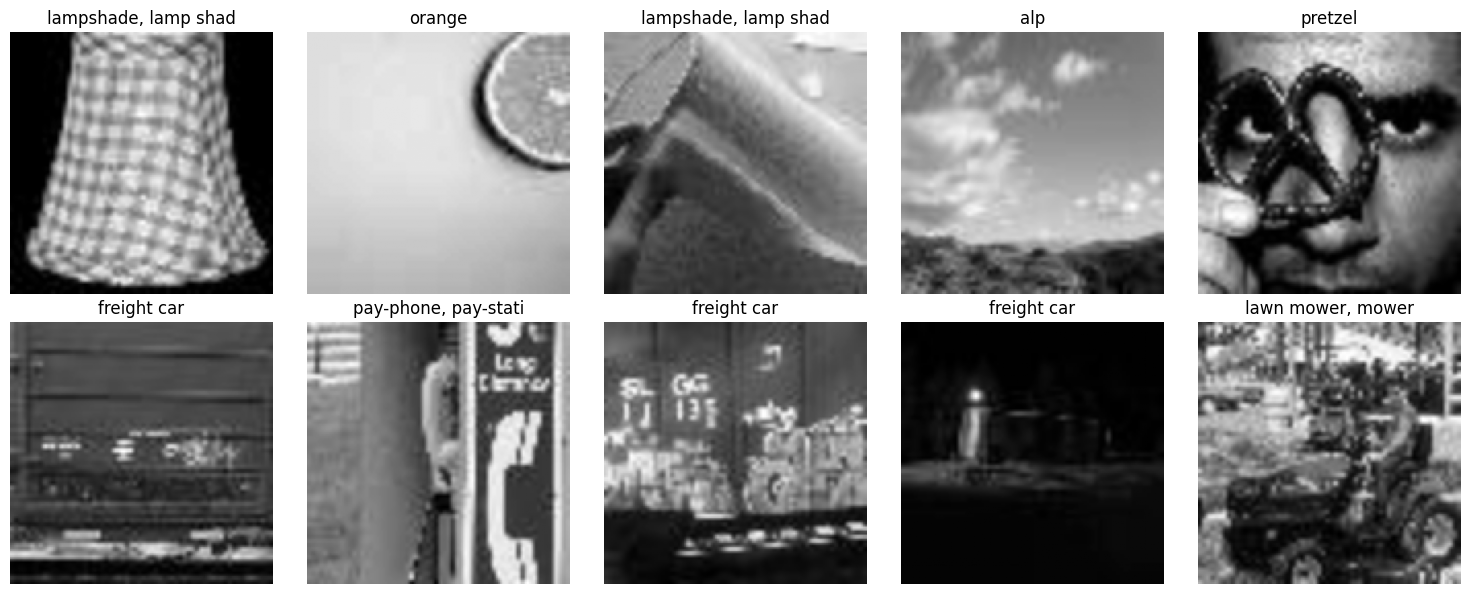

In [75]:
def show_sample_images(X, y, selected_classes, class_name_mapping, num_samples=10):
    plt.figure(figsize=(15, 6))
    indices = np.random.choice(len(X), num_samples, replace=False)

    for i, idx in enumerate(indices):
        plt.subplot(2, 5, i + 1)
        plt.imshow(X[idx], cmap="gray")
        class_id = selected_classes[y[idx]]
        title = class_name_mapping.get(class_id, class_id)
        plt.title(title[:20])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_sample_images(X_train, y_train, selected_classes, class_name_mapping)

In [76]:
def get_detector(method="sift"):
    method = method.lower()

    if method == "sift":
        return cv2.SIFT_create()
    elif method == "orb":
        return cv2.ORB_create(nfeatures=500)
    else:
        raise ValueError("method must be 'sift' or 'orb'")


def extract_local_descriptors(images, method="sift"):
    """
    Returns a list of descriptors for each image.
    Some images may return None if no keypoints are detected.
    """
    detector = get_detector(method)
    descriptors_list = []

    for img in images:
        keypoints, descriptors = detector.detectAndCompute(img, None)
        descriptors_list.append(descriptors)

    return descriptors_list

In [77]:
def build_visual_vocabulary(descriptors_list, vocab_size=100):
    """
    Stacks all valid descriptors and clusters them into visual words.
    """
    valid_descriptors = [d for d in descriptors_list if d is not None and len(d) > 0]

    if len(valid_descriptors) == 0:
        raise ValueError("No descriptors found. Cannot build vocabulary.")

    all_descriptors = np.vstack(valid_descriptors)
    print("Total descriptors for clustering:", all_descriptors.shape)

    kmeans = MiniBatchKMeans(
        n_clusters=vocab_size,
        random_state=RANDOM_SEED,
        batch_size=1000,
        n_init=10
    )
    kmeans.fit(all_descriptors)
    return kmeans

In [78]:
def compute_bow_histograms(descriptors_list, kmeans, vocab_size=100):
    """
    Converts each image's descriptors into a BoW histogram.
    """
    histograms = []

    for descriptors in descriptors_list:
        hist = np.zeros(vocab_size, dtype=np.float32)

        if descriptors is not None and len(descriptors) > 0:
            word_indices = kmeans.predict(descriptors)
            for idx in word_indices:
                hist[idx] += 1

        # Normalize histogram
        if hist.sum() > 0:
            hist = hist / hist.sum()

        histograms.append(hist)

    return np.array(histograms)

In [79]:
def plot_confusion_matrix(cm, class_labels, title):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.colorbar()

    ticks = np.arange(len(class_labels))
    plt.xticks(ticks, class_labels, rotation=90)
    plt.yticks(ticks, class_labels)

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

In [80]:
def run_bow_svm_pipeline(X_train, y_train, X_test, y_test, method="sift", vocab_size=100):
    print(f"\n========== {method.upper()} PIPELINE ==========")

    # 1. Extract descriptors
    print("Extracting training descriptors...")
    train_descriptors = extract_local_descriptors(X_train, method=method)

    print("Extracting testing descriptors...")
    test_descriptors = extract_local_descriptors(X_test, method=method)

    # 2. Build visual vocabulary
    print("Building visual vocabulary...")
    kmeans = build_visual_vocabulary(train_descriptors, vocab_size=vocab_size)

    # 3. Build BoW histograms
    print("Computing BoW histograms...")
    X_train_bow = compute_bow_histograms(train_descriptors, kmeans, vocab_size=vocab_size)
    X_test_bow = compute_bow_histograms(test_descriptors, kmeans, vocab_size=vocab_size)

    print("Train BoW shape:", X_train_bow.shape)
    print("Test BoW shape :", X_test_bow.shape)

    # 4. Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_bow)
    X_test_scaled = scaler.transform(X_test_bow)

    # 5. Train Linear SVM
    print("Training Linear SVM...")
    svm = LinearSVC(max_iter=5000, random_state=RANDOM_SEED)
    svm.fit(X_train_scaled, y_train)

    # 6. Predict
    y_pred = svm.predict(X_test_scaled)

    # 7. Evaluate
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"{method.upper()} Accuracy: {acc * 100:.2f}%")

    return {
        "method": method,
        "kmeans": kmeans,
        "scaler": scaler,
        "svm": svm,
        "y_pred": y_pred,
        "accuracy": acc,
        "confusion_matrix": cm
    }

In [81]:
sift_results = run_bow_svm_pipeline(
    X_train, y_train, X_test, y_test,
    method="sift",
    vocab_size=VOCAB_SIZE
)


========== SIFT PIPELINE ==========
Extracting training descriptors...
Extracting testing descriptors...
Building visual vocabulary...
Total descriptors for clustering: (775803, 128)
Computing BoW histograms...
Train BoW shape: (4000, 100)
Test BoW shape : (1000, 100)
Training Linear SVM...
SIFT Accuracy: 34.20%


In [82]:
orb_results = run_bow_svm_pipeline(
    X_train, y_train, X_test, y_test,
    method="orb",
    vocab_size=VOCAB_SIZE
)


========== ORB PIPELINE ==========
Extracting training descriptors...
Extracting testing descriptors...
Building visual vocabulary...
Total descriptors for clustering: (525536, 32)
Computing BoW histograms...
Train BoW shape: (4000, 100)
Test BoW shape : (1000, 100)
Training Linear SVM...
ORB Accuracy: 20.20%


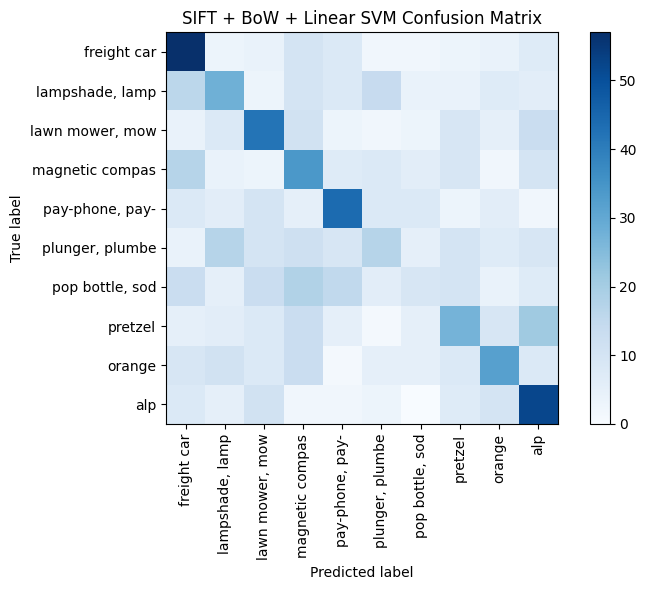

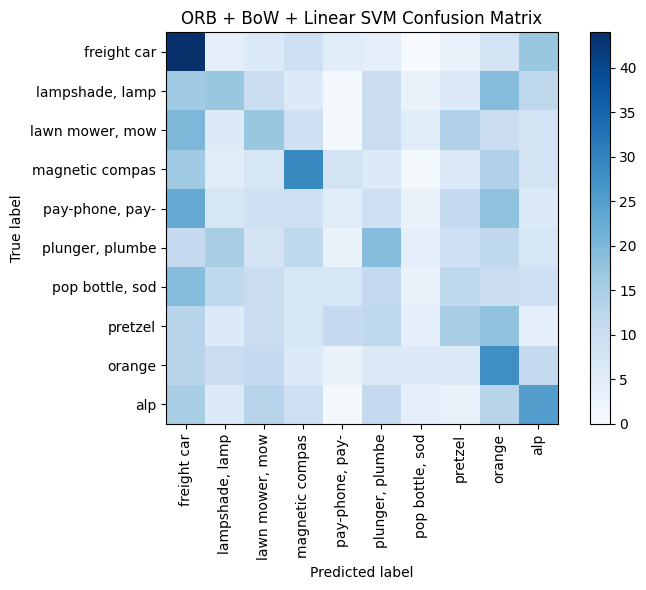

In [83]:
short_labels = [class_name_mapping.get(c, c)[:15] for c in selected_classes]

plot_confusion_matrix(
    sift_results["confusion_matrix"],
    short_labels,
    "SIFT + BoW + Linear SVM Confusion Matrix"
)

plot_confusion_matrix(
    orb_results["confusion_matrix"],
    short_labels,
    "ORB + BoW + Linear SVM Confusion Matrix"
)

In [84]:
print("SIFT Classification Report")
print(classification_report(y_test, sift_results["y_pred"], target_names=short_labels))

print("\nORB Classification Report")
print(classification_report(y_test, orb_results["y_pred"], target_names=short_labels))

SIFT Classification Report
                 precision    recall  f1-score   support

    freight car       0.40      0.57      0.47       100
lampshade, lamp       0.30      0.28      0.29       100
lawn mower, mow       0.38      0.42      0.40       100
magnetic compas       0.27      0.34      0.30       100
pay-phone, pay-       0.43      0.44      0.44       100
plunger, plumbe       0.26      0.17      0.20       100
pop bottle, sod       0.19      0.09      0.12       100
        pretzel       0.30      0.27      0.28       100
         orange       0.37      0.32      0.34       100
            alp       0.39      0.52      0.44       100

       accuracy                           0.34      1000
      macro avg       0.33      0.34      0.33      1000
   weighted avg       0.33      0.34      0.33      1000


ORB Classification Report
                 precision    recall  f1-score   support

    freight car       0.23      0.44      0.30       100
lampshade, lamp       0.19    

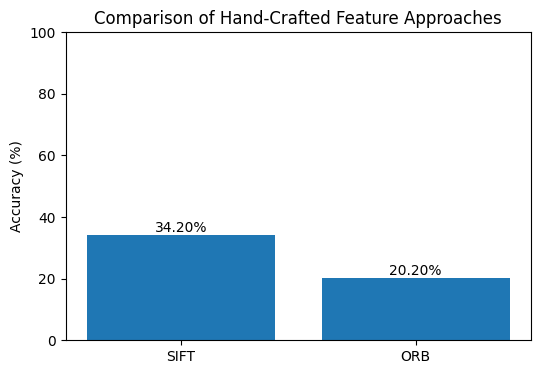

In [85]:
methods = ["SIFT", "ORB"]
accuracies = [sift_results["accuracy"] * 100, orb_results["accuracy"] * 100]

plt.figure(figsize=(6, 4))
plt.bar(methods, accuracies)
plt.ylabel("Accuracy (%)")
plt.title("Comparison of Hand-Crafted Feature Approaches")
plt.ylim(0, 100)
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha="center")
plt.show()